# Phase 4 - Step 1: Load Processed Data & Baseline Model

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

# Load the splits saved in Phase 3
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val = pd.read_csv('../data/processed/y_val.csv').squeeze()

print('Train shape:', X_train.shape, ' Fraud count:', y_train.sum())
print('Val shape:  ', X_val.shape, ' Fraud count:', y_val.sum())

Train shape: (198608, 30)  Fraud count: 331
Val shape:   (42559, 30)  Fraud count: 71


In [2]:
# BASELINE: plain Logistic Regression, no imbalance handling at all
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_val)
y_proba = baseline_model.predict_proba(X_val)[:, 1]

results = {}
results['Baseline'] = {
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'F1': f1_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_proba),
    'PR-AUC': average_precision_score(y_val, y_proba)
}

print('Baseline results:')
for k, v in results['Baseline'].items():
    print(f'{k}: {v:.4f}')

print('\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred))

Baseline results:
Precision: 0.8140
Recall: 0.4930
F1: 0.6140
ROC-AUC: 0.9655
PR-AUC: 0.6881

Confusion Matrix:
[[42480     8]
 [   36    35]]


# Step 2: Class Weights Approach

In [3]:
# class_weight='balanced' automatically penalizes mistakes on the minority class (fraud) more heavily
cw_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
cw_model.fit(X_train, y_train)

y_pred = cw_model.predict(X_val)
y_proba = cw_model.predict_proba(X_val)[:, 1]

results['Class Weights'] = {
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'F1': f1_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_proba),
    'PR-AUC': average_precision_score(y_val, y_proba)
}

print('Class Weights results:')
for k, v in results['Class Weights'].items():
    print(f'{k}: {v:.4f}')

print('\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred))

print('\nCompare to Baseline:')
print('Baseline Recall:', round(results['Baseline']['Recall'], 4), ' vs Class Weights Recall:', round(results['Class Weights']['Recall'], 4))

Class Weights results:
Precision: 0.0508
Recall: 0.8873
F1: 0.0960
ROC-AUC: 0.9719
PR-AUC: 0.6970

Confusion Matrix:
[[41310  1178]
 [    8    63]]

Compare to Baseline:
Baseline Recall: 0.493  vs Class Weights Recall: 0.8873


# Step 3: Undersampling

In [4]:
from imblearn.under_sampling import RandomUnderSampler

# Undersample the majority class (legit) to match the minority class (fraud) count
# IMPORTANT: only resample the TRAINING set. Never touch validation/test data,
# or evaluation will not reflect real-world class distribution.
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print('Before undersampling:', y_train.value_counts().to_dict())
print('After undersampling: ', y_train_under.value_counts().to_dict())

under_model = LogisticRegression(max_iter=1000, random_state=42)
under_model.fit(X_train_under, y_train_under)

y_pred = under_model.predict(X_val)
y_proba = under_model.predict_proba(X_val)[:, 1]

results['Undersampling'] = {
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'F1': f1_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_proba),
    'PR-AUC': average_precision_score(y_val, y_proba)
}

print('\nUndersampling results:')
for k, v in results['Undersampling'].items():
    print(f'{k}: {v:.4f}')

print('\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred))

Before undersampling: {0: 198277, 1: 331}
After undersampling:  {0: 331, 1: 331}

Undersampling results:
Precision: 0.0343
Recall: 0.8732
F1: 0.0661
ROC-AUC: 0.9773
PR-AUC: 0.5407

Confusion Matrix:
[[40745  1743]
 [    9    62]]


# Step 4: Random Oversampling

In [5]:
from imblearn.over_sampling import RandomOverSampler

# Oversample the minority class (fraud) by duplicating existing fraud rows
# until it matches the legit count. Only applied to TRAINING data.
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print('Before oversampling:', y_train.value_counts().to_dict())
print('After oversampling: ', y_train_over.value_counts().to_dict())

over_model = LogisticRegression(max_iter=1000, random_state=42)
over_model.fit(X_train_over, y_train_over)

y_pred = over_model.predict(X_val)
y_proba = over_model.predict_proba(X_val)[:, 1]

results['Oversampling'] = {
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'F1': f1_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_proba),
    'PR-AUC': average_precision_score(y_val, y_proba)
}

print('\nOversampling results:')
for k, v in results['Oversampling'].items():
    print(f'{k}: {v:.4f}')

print('\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred))

Before oversampling: {0: 198277, 1: 331}
After oversampling:  {0: 198277, 1: 198277}



Oversampling results:
Precision: 0.0509
Recall: 0.8873
F1: 0.0963
ROC-AUC: 0.9716
PR-AUC: 0.6990

Confusion Matrix:
[[41314  1174]
 [    8    63]]


# Step 5: SMOTE (Synthetic Minority Oversampling Technique)

In [6]:
from imblearn.over_sampling import SMOTE

# SMOTE creates NEW synthetic fraud examples by interpolating between existing
# fraud points and their nearest fraud neighbors, instead of just duplicating rows.
# This usually generalizes better than random oversampling. TRAINING data only.
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE: ', y_train_smote.value_counts().to_dict())

smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)

y_pred = smote_model.predict(X_val)
y_proba = smote_model.predict_proba(X_val)[:, 1]

results['SMOTE'] = {
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'F1': f1_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_proba),
    'PR-AUC': average_precision_score(y_val, y_proba)
}

print('\nSMOTE results:')
for k, v in results['SMOTE'].items():
    print(f'{k}: {v:.4f}')

print('\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred))

Before SMOTE: {0: 198277, 1: 331}
After SMOTE:  {0: 198277, 1: 198277}



SMOTE results:
Precision: 0.0490
Recall: 0.8873
F1: 0.0928
ROC-AUC: 0.9734
PR-AUC: 0.6987

Confusion Matrix:
[[41264  1224]
 [    8    63]]


# Step 6: Final Comparison Table

In [7]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)
comparison_df = comparison_df.sort_values('PR-AUC', ascending=False)

print('=== Class Imbalance Technique Comparison ===\n')
print(comparison_df)

print('\nBest technique by PR-AUC (most reliable metric for imbalanced data):')
print(comparison_df.index[0])

=== Class Imbalance Technique Comparison ===

               Precision  Recall      F1  ROC-AUC  PR-AUC
Oversampling      0.0509  0.8873  0.0963   0.9716  0.6990
SMOTE             0.0490  0.8873  0.0928   0.9734  0.6987
Class Weights     0.0508  0.8873  0.0960   0.9719  0.6970
Baseline          0.8140  0.4930  0.6140   0.9655  0.6881
Undersampling     0.0343  0.8732  0.0661   0.9773  0.5407

Best technique by PR-AUC (most reliable metric for imbalanced data):
Oversampling


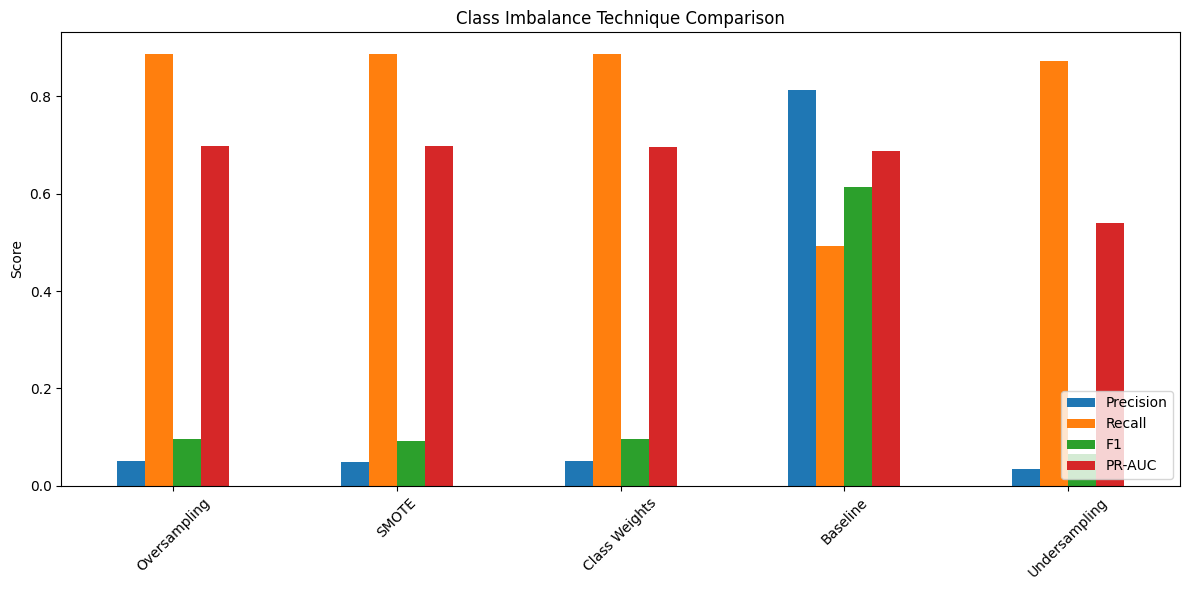

In [8]:
# Visualize the comparison
import matplotlib.pyplot as plt

comparison_df[['Precision', 'Recall', 'F1', 'PR-AUC']].plot(kind='bar', figsize=(12,6))
plt.title('Class Imbalance Technique Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [9]:
# Save the comparison results for the report/documentation later
import os
os.makedirs('../models', exist_ok=True)
comparison_df.to_csv('../models/class_imbalance_comparison.csv')
print('Saved comparison table to models/class_imbalance_comparison.csv')

Saved comparison table to models/class_imbalance_comparison.csv
